In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/final/base_dataset.csv")

In [3]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["latest_date"] = pd.to_datetime(df["latest_date"], errors="coerce")

today = pd.Timestamp.today()

In [6]:
df_engagement = df.copy()

df_engagement["game_age_days"] = (today - df_engagement["release_date"]).dt.days
df_engagement["players_per_review"] = df_engagement["current_players"] / df_engagement["total_reviews"]
df_engagement["log_players"] = np.log1p(df_engagement["current_players"])

df_engagement.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,game_age_days,players_per_review,log_players
0,730,Counter-Strike 2,2012-08-21,1,0.0,1,9549900,8229202,1320698,0.861706,1380146,2026-04-22 18:40:51,patchnotes,5004.0,0.144519,14.137701
1,570,Dota 2,NaT,1,0.0,2,2699057,2183308,515749,0.808915,540425,2026-04-07 16:24:46,patchnotes,NaN,0.200227,13.200113
2,440,Team Fortress 2,NaT,1,0.0,1,1227038,1115101,111937,0.908775,46100,2026-03-11 15:33:26,patchnotes,NaN,0.037570,10.738590
3,578080,PUBG: BATTLEGROUNDS,NaT,1,0.0,0,2702207,1628518,1073689,0.602662,280946,2026-04-23 14:23:44,NaN,NaN,0.103969,12.545921
4,271590,Grand Theft Auto V Legacy,NaT,0,NaN,0,2055185,1800114,255071,0.875889,79496,2026-04-17 10:40:18,hide_store,NaN,0.038681,11.283475


In [7]:
df_reviews_feat = df.copy()

df_reviews_feat["positive_percent"] = df_reviews_feat["total_positive"] / df_reviews_feat["total_reviews"]

df_reviews_feat["review_score_bucket"] = pd.cut(
    df_reviews_feat["positive_percent"],
    bins=[0, 0.5, 0.7, 0.85, 1],
    labels=["low", "mixed", "good", "excellent"]
)

df_reviews_feat.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,positive_percent,review_score_bucket
0,730,Counter-Strike 2,2012-08-21,1,0.0,1,9549900,8229202,1320698,0.861706,1380146,2026-04-22 18:40:51,patchnotes,0.861706,excellent
1,570,Dota 2,NaT,1,0.0,2,2699057,2183308,515749,0.808915,540425,2026-04-07 16:24:46,patchnotes,0.808915,good
2,440,Team Fortress 2,NaT,1,0.0,1,1227038,1115101,111937,0.908775,46100,2026-03-11 15:33:26,patchnotes,0.908775,excellent
3,578080,PUBG: BATTLEGROUNDS,NaT,1,0.0,0,2702207,1628518,1073689,0.602662,280946,2026-04-23 14:23:44,NaN,0.602662,mixed
4,271590,Grand Theft Auto V Legacy,NaT,0,NaN,0,2055185,1800114,255071,0.875889,79496,2026-04-17 10:40:18,hide_store,0.875889,excellent


In [8]:
df_support = df.copy()

df_support["days_since_update"] = (today - df_support["latest_date"]).dt.days

df_support["recent_update"] = df_support["days_since_update"] < 30

df_support["has_patchnotes"] = df_support["tags"].str.contains("patchnotes", na=False)

df_support.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,days_since_update,recent_update,has_patchnotes
0,730,Counter-Strike 2,2012-08-21,1,0.0,1,9549900,8229202,1320698,0.861706,1380146,2026-04-22 18:40:51,patchnotes,11,True,True
1,570,Dota 2,NaT,1,0.0,2,2699057,2183308,515749,0.808915,540425,2026-04-07 16:24:46,patchnotes,26,True,True
2,440,Team Fortress 2,NaT,1,0.0,1,1227038,1115101,111937,0.908775,46100,2026-03-11 15:33:26,patchnotes,53,False,True
3,578080,PUBG: BATTLEGROUNDS,NaT,1,0.0,0,2702207,1628518,1073689,0.602662,280946,2026-04-23 14:23:44,NaN,10,True,False
4,271590,Grand Theft Auto V Legacy,NaT,0,NaN,0,2055185,1800114,255071,0.875889,79496,2026-04-17 10:40:18,hide_store,17,True,False


In [ ]:
df_money = df.copy()

df_money["is_paid"] = ~df_money["is_free"]

df_money["price_bucket"] = pd.cut(
    df_money["price_usd"],
    bins=[0, 10, 30, 60, 100],
    labels=["cheap", "mid", "premium", "expensive"],
    include_lowest=True
)

df_money["price_bucket"] = df_money["price_bucket"].cat.add_categories(["free"])

df_money.loc[df_money["is_free"], "price_bucket"] = "free"

df_money.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,is_paid,price_bucket
0,730,Counter-Strike 2,2012-08-21,1,0.0,1,9549900,8229202,1320698,0.861706,1380146,2026-04-22 18:40:51,patchnotes,-2,free
1,570,Dota 2,NaT,1,0.0,2,2699057,2183308,515749,0.808915,540425,2026-04-07 16:24:46,patchnotes,-2,free
2,440,Team Fortress 2,NaT,1,0.0,1,1227038,1115101,111937,0.908775,46100,2026-03-11 15:33:26,patchnotes,-2,cheap
3,578080,PUBG: BATTLEGROUNDS,NaT,1,0.0,0,2702207,1628518,1073689,0.602662,280946,2026-04-23 14:23:44,NaN,-2,cheap
4,271590,Grand Theft Auto V Legacy,NaT,0,NaN,0,2055185,1800114,255071,0.875889,79496,2026-04-17 10:40:18,hide_store,-1,NaN


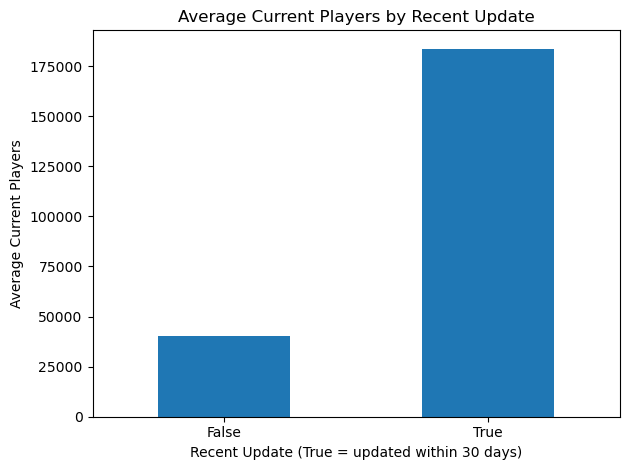

In [16]:
grouped = df_support.groupby("recent_update")["current_players"].mean()

grouped.plot(kind="bar")

plt.title("Average Current Players by Recent Update")
plt.xlabel("Recent Update (True = updated within 30 days)")
plt.ylabel("Average Current Players")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\mmaur\AppData\Local\Temp\ipykernel_8568\519539247.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_group = df_reviews_feat.groupby("review_score_bucket")["current_players"].mean()


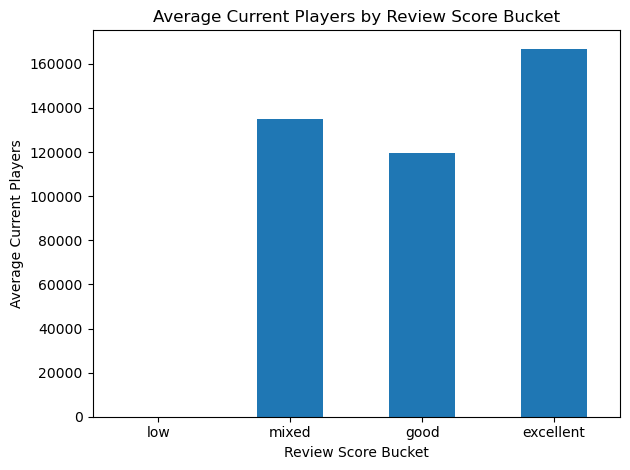

In [17]:
review_group = df_reviews_feat.groupby("review_score_bucket")["current_players"].mean()

review_group.plot(kind="bar")

plt.title("Average Current Players by Review Score Bucket")
plt.xlabel("Review Score Bucket")
plt.ylabel("Average Current Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

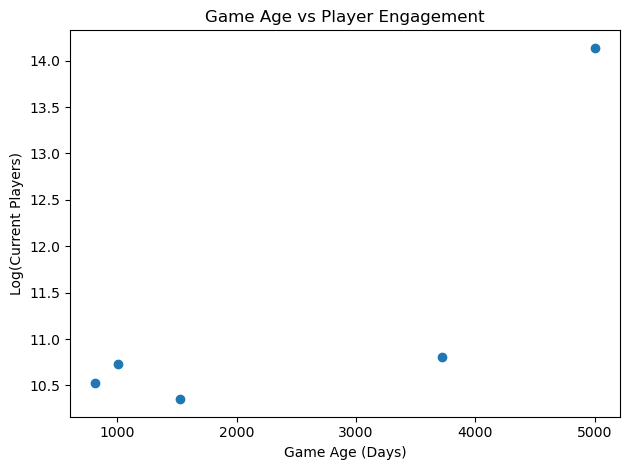

In [18]:
plt.scatter(df_engagement["game_age_days"], df_engagement["log_players"])

plt.title("Game Age vs Player Engagement")
plt.xlabel("Game Age (Days)")
plt.ylabel("Log(Current Players)")
plt.tight_layout()
plt.show()

C:\Users\mmaur\AppData\Local\Temp\ipykernel_8568\169601064.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_group = df_money.groupby("price_bucket")["current_players"].mean()


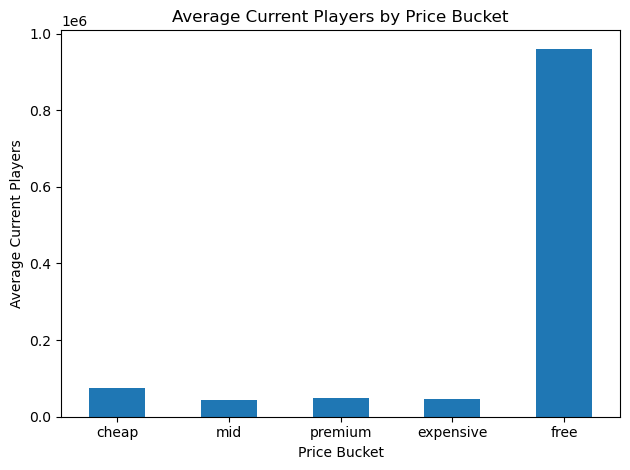

In [19]:
price_group = df_money.groupby("price_bucket")["current_players"].mean()

price_group.plot(kind="bar")

plt.title("Average Current Players by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Average Current Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()